### Redes neuronales y TensorFlow con el problema de la espiral

Generamos un dataset de una espiral que está formada por dos conjuntos o cluters.

In [ ]:
# =============================================================================
# Importar bibliotecas necesarias
# =============================================================================
# NumPy: Para manejar arrays y operaciones matemáticas.
import numpy as np
# Matplotlib: Para crear gráficos y visualizaciones.
import matplotlib.pyplot as plt
# TensorFlow y Keras: Para definir y entrenar la red neuronal.
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
# Scikit-learn: Para dividir los datos en conjuntos de entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# =============================================================================
# Generar datos en espiral
# =============================================================================
# Fijamos una semilla para que los resultados sean reproducibles.
np.random.seed(42)
# Número de puntos por clase.
N = 1000
# Generamos ángulos aleatorios entre 0 y 2π.
theta = np.sqrt(np.random.rand(N)) * 2 * np.pi
# Radios para las dos espirales.
r_a = 2 * theta + np.pi  # Espiral A
r_b = -2 * theta - np.pi  # Espiral B

# Generamos los datos para la primera clase (clase 0).
# Cada punto tiene coordenadas (x, y) calculadas usando seno y coseno.
data_a = np.array([np.sin(theta) * r_a, np.cos(theta) * r_a]).T
label_a = np.zeros(N)  # Etiquetas para la clase 0

# Generamos los datos para la segunda clase (clase 1).
data_b = np.array([np.sin(theta) * r_b, np.cos(theta) * r_b]).T
label_b = np.ones(N)  # Etiquetas para la clase 1

# Combinamos los datos y las etiquetas de ambas clases.
data = np.vstack((data_a, data_b))
labels = np.concatenate((label_a, label_b))

# =============================================================================
# Dividir los datos en conjuntos de entrenamiento y prueba
# =============================================================================
# 70% de los datos para entrenamiento, 30% para prueba.
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42)

# =============================================================================
# Definir el modelo de la red neuronal
# =============================================================================
# Creamos un modelo secuencial (una pila de capas).
model = Sequential([
    # Primera capa oculta: 64 neuronas, función de activación ReLU.
    # input_shape=(2,) indica que cada entrada tiene 2 características (x, y).
    # kernel_regularizer=l2(0.01) añade regularización L2 para evitar sobreajuste.
    Dense(64, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.01)),

    # Segunda capa oculta: 64 neuronas, función de activación ReLU.
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),

    # Capa de salida: 1 neurona, función de activación sigmoide.
    # Ideal para clasificación binaria (dos clases).
    Dense(1, activation='sigmoid')
])

# =============================================================================
# Compilar el modelo
# =============================================================================
# Definimos el optimizador (adam), la función de pérdida (binary_crossentropy)
# y la métrica a monitorear (accuracy).
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =============================================================================
# Entrenar el modelo
# =============================================================================
# Entrenamos el modelo con los datos de entrenamiento.
# epochs=200: El modelo verá los datos 200 veces.
# batch_size=32: Actualiza los pesos cada 32 muestras.
# validation_split=0.2: Usa el 20% de los datos de entrenamiento para validación.
print("Entrenando el modelo...")
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, verbose=10)

# =============================================================================
# Evaluar el modelo
# =============================================================================
# Evaluamos el modelo con los datos de prueba.
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en el conjunto de prueba: {test_acc:.4f}")

# =============================================================================
# Guardar el modelo entrenado
# =============================================================================
# Guardamos el modelo en un archivo para usarlo más tarde.
model.save('modelo_espiral.keras')
print("Modelo guardado como 'modelo_espiral.keras'")

# =============================================================================
# Visualizar la pérdida y precisión durante el entrenamiento
# =============================================================================
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    # Gráfico de la pérdida durante el entrenamiento.
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida en entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida en validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.legend()

    # Gráfico de la precisión durante el entrenamiento.
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión en entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión en validación')
    plt.title('Precisión durante el entrenamiento')
    plt.legend()
    plt.show()

plot_training_history(history)

# =============================================================================
# Visualizar los datos y la frontera de decisión
# =============================================================================
def plot_decision_boundary(model, X, y):
    # Definimos los límites del gráfico.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    # Creamos una malla de puntos para evaluar el modelo.
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    # Predecimos la clase para cada punto de la malla.
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = (Z > 0.5).astype(int)  # Convertimos las probabilidades a clases (0 o 1).
    Z = Z.reshape(xx.shape)

    # Dibujamos la frontera de decisión y los datos.
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.title("Frontera de decisión para el problema de la espiral")
    plt.show()

plot_decision_boundary(model, data, labels)


Explicación de los bloques principales:

- Generación de datos: Crea dos espirales entrelazadas y asigna etiquetas a cada punto.
- División de datos: Separa los datos en conjuntos de entrenamiento y prueba.
- Definición del modelo: Crea una red neuronal con dos capas ocultas y regularización L2.
- Entrenamiento: Ajusta los pesos de la red para minimizar la pérdida.

**Evaluación**: Mide la precisión del modelo en datos no vistos.

**Visualización**: Muestra gráficos de la pérdida, precisión y la frontera de decisión aprendida.

## ¿Qué es un archivo .h5/.keras en TensorFlow/Keras?

Un archivo .h5 (depreciado) .keras (actual) es un formato de archivo utilizado por Keras (parte de TensorFlow) para guardar modelos entrenados. Este archivo contiene:

- La arquitectura del modelo (número de capas, neuronas, funciones de activación, etc.).
- Los pesos aprendidos durante el entrenamiento.
- El optimizador y su estado (si se guarda).
- Cualquier otra información necesaria para reconstruir y usar el modelo exactamente como estaba al guardarlo.

En resumen, es una "foto" completa de tu modelo entrenado, lista para ser cargada y usada después sin necesidad de volver a entrenarlo.

## ¿Cómo se usa un modelo guardado en .h5?
1. Cargar el modelo
Para usar el modelo guardado, primero debes cargarlo en tu script o notebook. Esto se hace con la función load_model de Keras:

In [3]:
from tensorflow.keras.models import load_model

# Cargar el modelo guardado
modelo_cargado = load_model('modelo_espiral.keras')


2. Hacer predicciones
Una vez cargado, puedes usar el modelo para hacer predicciones sobre nuevos datos. Por ejemplo, si tienes nuevos puntos en forma de espiral, puedes predecir a qué clase pertenecen:

In [11]:
print(data_a[0])
print(data_b[1])

[-7.00885668 -8.25904777]
[  2.4038362  -15.20554149]


In [13]:
# Ejemplo: Supongamos que tienes nuevos datos en la variable 'nuevos_datos'
# nuevos_datos debe ser un array de NumPy con la misma forma que los datos de entrenamiento (en este caso, [n_muestras, 2])

predicciones = modelo_cargado.predict(np.array([[-7, -8]]), verbose=0)

# Las predicciones son probabilidades entre 0 y 1.
# Puedes convertirlas a clases (0 o 1) usando un umbral (por ejemplo, 0.5):
clases_predichas = (predicciones > 0.5).astype(int)
print("Pertenece a la clase:", clases_predichas)


Pertenece a la clase: [[0]]


3. Evaluar el modelo
También puedes evaluar el modelo cargado con nuevos datos para medir su precisión:

In [14]:
# Supongamos que tienes datos de prueba en X_test y y_test
pérdida, precisión = modelo_cargado.evaluate(X_test, y_test, verbose=0)
print(f"Precisión del modelo cargado: {precisión:.4f}")


Precisión del modelo cargado: 1.0000


4. Visualizar la frontera de decisión
Si quieres visualizar cómo clasifica el modelo los datos (como hicimos antes), puedes reutilizar la función plot_decision_boundary:

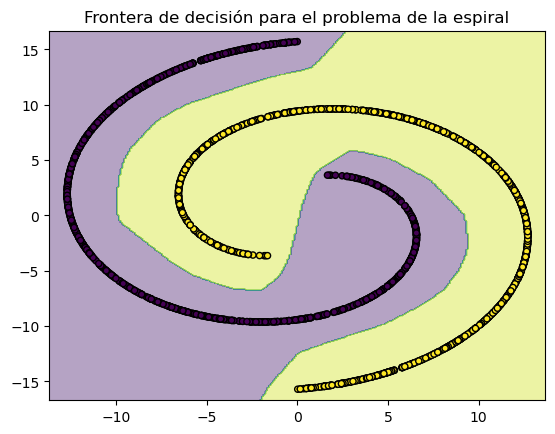

In [15]:
plot_decision_boundary(modelo_cargado, data, labels)


Ejemplo completo:

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np

# 1. Cargar el modelo
modelo_cargado = load_model('modelo_espiral.keras')

# 2. Generar nuevos datos de ejemplo (opcional)
np.random.seed(42)
N = 100
theta = np.sqrt(np.random.rand(N)) * 2 * np.pi
r_a = 2 * theta + np.pi
r_b = -2 * theta - np.pi

nuevos_datos_a = np.array([np.sin(theta) * r_a, np.cos(theta) * r_a]).T
nuevos_datos_b = np.array([np.sin(theta) * r_b, np.cos(theta) * r_b]).T
nuevos_datos = np.vstack((nuevos_datos_a, nuevos_datos_b))

# 3. Hacer predicciones
predicciones = modelo_cargado.predict(nuevos_datos)
clases_predichas = (predicciones > 0.5).astype(int)
print("Clases predichas para los nuevos datos:", clases_predichas)

# 4. Evaluar el modelo (opcional, si tienes datos de prueba)
# pérdida, precisión = modelo_cargado.evaluate(X_test, y_test, verbose=0)
# print(f"Precisión del modelo cargado: {precisión:.4f}")

# 5. Visualizar la frontera de decisión (opcional)
plot_decision_boundary(modelo_cargado, data, labels)


**¿Por qué es útil guardar el modelo?**

* Reutilización: Puedes usar el modelo en otros scripts o aplicaciones sin tener que entrenarlo de nuevo.
* Despliegue: Es el primer paso para desplegar el modelo en una aplicación web, móvil o en la nube.
* Compartir: Puedes compartir el modelo con otros para que lo usen o lo evalúen.

### Modelos

Cuando trabajas con redes neuronales en TensorFlow/Keras, tienes una amplia variedad de modelos y opciones de optimización para elegir, dependiendo del tipo de problema que quieras resolver. Aquí te explico los modelos más comunes y las opciones de optimización disponibles, con ejemplos prácticos para que puedas aplicarlos en tu contexto.

1. Tipos de Modelos en TensorFlow/Keras
    - Modelo Secuencial (Sequential)

        * ¿Qué es?: Una pila lineal de capas. Es el tipo de modelo más simple y común para problemas básicos.
        * Uso típico: Clasificación, regresión, problemas con datos tabulares.
        * Ejemplo:


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


1. cont...
    - Modelo Funcional (Model)

        * ¿Qué es?: Permite definir modelos con topologías más complejas (ej. múltiples entradas/salidas, conexiones no lineales).
        * Uso típico: Redes con múltiples entradas o salidas, modelos personalizados.
        * Ejemplo:

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(2,))
x = Dense(64, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inputs, outputs=outputs)


1. cont...
    - Redes Convolucionales (CNN)

        * ¿Qué es?: Especializadas en procesar datos con estructura de cuadrícula (ej. imágenes).
        * Uso típico: Clasificación de imágenes, detección de objetos.
        * Ejemplo:


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


1. cont...
    - Redes Recurrentes (RNN, LSTM, GRU)
        * ¿Qué es?: Diseñadas para procesar secuencias de datos (ej. series temporales, texto).
        * Uso típico: Predicción de series temporales, procesamiento de lenguaje natural.
        * Ejemplo:

In [ ]:
from tensorflow.keras.layers import LSTM

model = Sequential([
    LSTM(64, input_shape=(10, 1)),
    Dense(1)
])


2. Opciones de Optimización
    - Optimizadores
        Los optimizadores ajustan los pesos de la red para minimizar la función de pérdida. Los más comunes son:
        * SGD (Stochastic Gradient Descent):

            - Uso: Optimizador básico, útil para entender el proceso de aprendizaje.
            - Ejemplo:

In [ ]:
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])


2. cont...
    - Optimizadores
       * Adam:
            * Uso: Adaptativo, combina las ventajas de otros optimizadores. Es el más usado por defecto.
            * Ejemplo:

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


2. cont...
    - Optimizadores
        * RMSprop:
            * Uso: Adaptativo, ideal para redes recurrentes.
            * Ejemplo:

In [ ]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])


2. Funciones de Pérdida (Loss Functions)
    - Clasificación binaria: binary_crossentropy
    - Clasificación multiclase: categorical_crossentropy o sparse_categorical_crossentropy
    - Regresión: mean_squared_error (MSE)

3. Métricas
    - Clasificación: accuracy
    - Regresión: mean_absolute_error (MAE)

4. Regularización
L1/L2: Penaliza los pesos grandes para evitar sobreajuste.


In [ ]:
from tensorflow.keras.regularizers import l1, l2
Dense(64, activation='relu', kernel_regularizer=l2(0.01))


Dropout: Apaga aleatoriamente neuronas durante el entrenamiento.

In [ ]:
from tensorflow.keras.layers import Dropout
model.add(Dropout(0.5))


3. ¿Cómo Elegir?
    - Modelo:
        * Datos tabulares: Sequential o Model.
        * Imágenes: CNN.
        * Secuencias: RNN, LSTM, GRU.

    - Optimizador:
        * Por defecto: Usa Adam.
        * Problemas específicos: Prueba RMSprop para RNN o ajusta SGD con momentum.

    - Regularización:
        Si el modelo sobreajusta, añade Dropout o regularización L2.

4. Ejemplo Práctico para el Problema de la Espiral

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Definir el modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.01)),
    Dropout(0.3), # Añadir Dropout para regularización, 0.3 es la tasa de dropout
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo con el optimizador Adam
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2)


### Resumen

Modelos: Elige según la estructura de tus datos.
Optimización: Adam es una opción segura, pero ajusta según el problema.
Regularización: Usa Dropout o L2 si el modelo sobreajusta.